## **Was verändert sich zuerst – Leistungsniveau oder Altersstruktur?**

### **1. Kernidee**

Die Meta-Frage zielt darauf ab, **Strukturwandel von Leistungswandel zu trennen** und ihre **zeitliche Reihenfolge** zu bestimmen.

> Verbessert sich zuerst
> 
> 
> *wer*
> 

> oder zuerst
> 
> 
> *wie gut*
> 

Diese Unterscheidung ist zentral, weil beide Prozesse **unterschiedliche Ursachen** haben.

In [18]:
from pathlib import Path
import sys
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import plotting.plotting_style as plt
import util
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import ruptures as rpt


In [19]:
df = util.load_data("../../data_csv/final_Data_iaaf_scores_neu.csv")
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
224454,2023,W,Frauen,Siebenkampf,4934.00,NaN,Meret Joeris,2004,USC Mainz,20.05.2023,Filderstadt,868
224455,2023,W,Frauen,Siebenkampf,4929.00,NaN,Sofie Groeninger,2005,LG Sempt,20.05.2023,Filderstadt,867
224456,2023,W,Frauen,Siebenkampf,4840.00,NaN,Franziska Decker,1999,LG Rhein-Wied,12.05.2023,Jacksonville FL (USA),850
224457,2023,W,Frauen,Siebenkampf,4826.00,NaN,Lena Kerkloh,1995,LG Reinbek/Ohe,13.05.2023,Papenburg,847


### **A. Altersstruktur ändert sich zuerst →**

### **Systemischer Effekt**

Typische Ursachen:

- Talentidentifikation
- Nachwuchsprogramme
- Selektionsregeln
- veränderte Karrierepfade

**Beobachtbares Muster**

- Median-Alter Top-X sinkt / steigt
- Alters-IQR verändert sich
- Leistungsniveau bleibt zunächst konstant
- Leistungsanstieg folgt zeitverzögert

**Interpretation**

> Das System produziert
> 
> 
> *andere*
> 
> *bessere*
> 

---

### **B. Leistungsniveau ändert sich zuerst →**

### **Technischer / externer Effekt**

Typische Ursachen:

- Trainingsmethoden
- Material
- Regeländerungen
- medizinische Fortschritte

**Beobachtbares Muster**

- Jahresbestleistungen verbessern sich abrupt
- Altersverteilung bleibt stabil
- Altersstruktur reagiert verzögert oder gar nicht

**Interpretation**

> Alle profitieren gleichzeitig, unabhängig vom Alter.
>

### **3.1 Definiere zwei Zeitreihen**

**Leistungsniveau L(t)**

Beispiele:

- Jahresbestleistung
- Median der Top-5 / Top-10
- 10-%-Quantil

**Altersstruktur A(t)**

Beispiele:

- Median-Alter Top-X
- IQR des Alters Top-X
- Alter des Median-Performers

In [20]:
TOP_X = 10

df_valid = df.copy()

df_valid['alter'] = df_valid['jahr'] - df_valid['geburtsjahr']

df_valid['athlete_id'] = (
    df_valid['name'].str.lower().str.strip().str.replace(' ', '_', regex=False)
    + '_' + df_valid['geburtsjahr'].astype(str)
)

df_valid = (
    df_valid
    .sort_values('iaaf_score', ascending=False)
    .groupby(['athlete_id', 'jahr', 'geschlecht'], as_index=False)
    .first()
)


df_top = (
    df_valid
    .sort_values(['jahr', 'iaaf_score'], ascending=[True, False])
    .groupby(['jahr', 'disziplin', 'geschlecht'])
    .head(TOP_X)
)

df_top

,athlete_id,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,alter
36751,lars_riedel_1967,2001,M,Maenner,Diskuswurf,69.72,NaN,Lars Riedel,1967,LAC Erdgas Chemnitz,08.08.,Edmonton/CAN,1240,34
46713,martin_buss_1976,2001,M,Maenner,Hochsprung,2.36,0.5,Martin Buss,1976,TSV Bayer Leverkusen,08.08.,Edmonton/CAN,1233,25
58933,raymond_hecht_1968,2001,M,Maenner,Speerwurf,88.88,NaN,Raymond Hecht,1968,SC Magdeburg,17.08.,Zuerich/SUI,1228,33
57224,peter_blank_1962,2001,M,Maenner,Speerwurf,88.70,NaN,Peter Blank,1962,LG Eintracht Frankfurt,30.06.,Stuttgart,1226,39
13242,daniel_ecker_1977,2001,M,Maenner,Stabhochsprung,5.85,NaN,Daniel Ecker,1977,TSV Bayer Leverkusen,30.06.,Stuttgart,1225,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11755,christoph_maennel_2005,2024,M,20,3000 m,513.99,NaN,Christoph Maennel,2005,SC DHfK Leipzig,25.05.2024,Regensburg,866,19
54926,noah_moeller_2008,2024,M,18,2000 m Hindernis,369.85,NaN,Noah Moeller,2008,TSV 1860 Staffelstein,05.07.2024,Moenchengladbach,861,16
15129,diego_wald_2007,2024,M,18,2000 m Hindernis,370.27,NaN,Diego Wald,2007,SC Neubrandenburg,19.05.2024,Zeven,859,17
41438,luis_butterwegge_2007,2024,M,20,3000 m,515.34,NaN,Luis Butterwegge,2007,LC Paderborn,26.07.2024,Koblenz,859,17


In [21]:
L = (
    df_top
    .groupby(['jahr', 'geschlecht', 'disziplin'])['iaaf_score']
    .median()
    .rename('L')
    .reset_index()
)

L

,jahr,geschlecht,disziplin,L
0,2001,M,10 000 m,1026.5
1,2001,M,10 km,989.0
2,2001,M,100 m,1048.0
3,2001,M,110 m Huerden,1133.0
4,2001,M,1500 m,1068.0
...,...,...,...,...
1080,2024,W,Marathon,1124.5
1081,2024,W,Siebenkampf,1050.5
1082,2024,W,Speerwurf,1039.5
1083,2024,W,Stabhochsprung,1024.0


In [22]:
A = (
    df_top
    .groupby(['jahr', 'geschlecht', 'disziplin'])['alter']
    .agg(
        A_median='median',
        A_q25=lambda x: np.percentile(x, 25),
        A_q75=lambda x: np.percentile(x, 75),
    )
    .reset_index()
)
A['A_iqr'] = A['A_q75'] - A['A_q25']

A

,jahr,geschlecht,disziplin,A_median,A_q25,A_q75,A_iqr
0,2001,M,10 000 m,28.0,24.25,29.75,5.50
1,2001,M,10 km,28.5,26.50,31.00,4.50
2,2001,M,100 m,22.5,20.50,26.50,6.00
3,2001,M,110 m Huerden,22.5,18.25,28.75,10.50
4,2001,M,1500 m,24.5,22.25,26.50,4.25
...,...,...,...,...,...,...,...
1080,2024,W,Marathon,32.0,30.50,33.75,3.25
1081,2024,W,Siebenkampf,22.0,21.00,24.75,3.75
1082,2024,W,Speerwurf,24.0,21.75,24.00,2.25
1083,2024,W,Stabhochsprung,25.0,20.50,28.75,8.25


In [23]:
ts = (
    L
    .merge(A, on=['jahr', 'geschlecht', 'disziplin'])
    .sort_values('jahr')
)

ts

,jahr,geschlecht,disziplin,L,A_median,A_q25,A_q75,A_iqr
0,2001,M,10 000 m,1026.5,28.0,24.25,29.75,5.50
25,2001,W,100 m,1053.0,21.5,19.00,23.00,4.00
26,2001,W,100 m Huerden,1100.0,21.5,19.25,24.00,4.75
27,2001,W,1500 m,1050.5,24.0,20.50,26.75,6.25
28,2001,W,200 m,1032.0,25.5,19.25,28.00,8.75
...,...,...,...,...,...,...,...,...
1056,2024,M,Kugelstoss,1096.5,21.0,20.00,22.75,2.75
1057,2024,M,Marathon,1167.0,30.5,29.25,32.75,3.50
1058,2024,M,Speerwurf,1050.5,21.5,20.00,27.00,7.00
1048,2024,M,400 m,1110.0,25.0,21.50,26.00,4.50


### **3.2 Betrachte**

### **Änderungen**

### **, nicht Niveaus**

Arbeite mit Differenzen:

- ΔL(t) = L(t) − L(t−1)
- ΔA(t) = A(t) − A(t−1)

Das entfernt langsame Trends und fokussiert auf **Umbrüche**.

In [24]:
for col in ['L', 'A_median', 'A_iqr']:
    ts[f'd{col}'] = ts.groupby(
        ['disziplin', 'geschlecht']
    )[col].diff()

ts

,jahr,geschlecht,disziplin,L,A_median,A_q25,A_q75,A_iqr,dL,dA_median,dA_iqr
0,2001,M,10 000 m,1026.5,28.0,24.25,29.75,5.50,NaN,NaN,NaN
25,2001,W,100 m,1053.0,21.5,19.00,23.00,4.00,NaN,NaN,NaN
26,2001,W,100 m Huerden,1100.0,21.5,19.25,24.00,4.75,NaN,NaN,NaN
27,2001,W,1500 m,1050.5,24.0,20.50,26.75,6.25,NaN,NaN,NaN
28,2001,W,200 m,1032.0,25.5,19.25,28.00,8.75,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1056,2024,M,Kugelstoss,1096.5,21.0,20.00,22.75,2.75,-20.5,0.0,-6.25
1057,2024,M,Marathon,1167.0,30.5,29.25,32.75,3.50,12.0,1.0,1.00
1058,2024,M,Speerwurf,1050.5,21.5,20.00,27.00,7.00,4.5,-2.0,-1.25
1048,2024,M,400 m,1110.0,25.0,21.50,26.00,4.50,15.0,0.0,1.00


In [25]:
sub = ts[
    (ts['disziplin'] == '100 m') &
    (ts['geschlecht'] == 'M')
].sort_values('jahr')


with plt.rc_context(plt.increase_figsize(1.8)):

    fig, ax1 = plt.subplots()

    ax1.plot(
        sub['jahr'],
        sub['L'],
        marker='o',
        label='Leistung'
    )

    ax1.set_ylabel('Leistung')
    ax1.set_xlabel('Jahr')

    ax2 = ax1.twinx()
    ax2.plot(
        sub['jahr'],
        sub['A_median'],
        marker='s',
        linestyle='--',
        label='Median-Alter',
        color=plt.rgb.tue_darkblue
    )
    ax2.set_ylabel('Alter')

    ax1.grid()
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

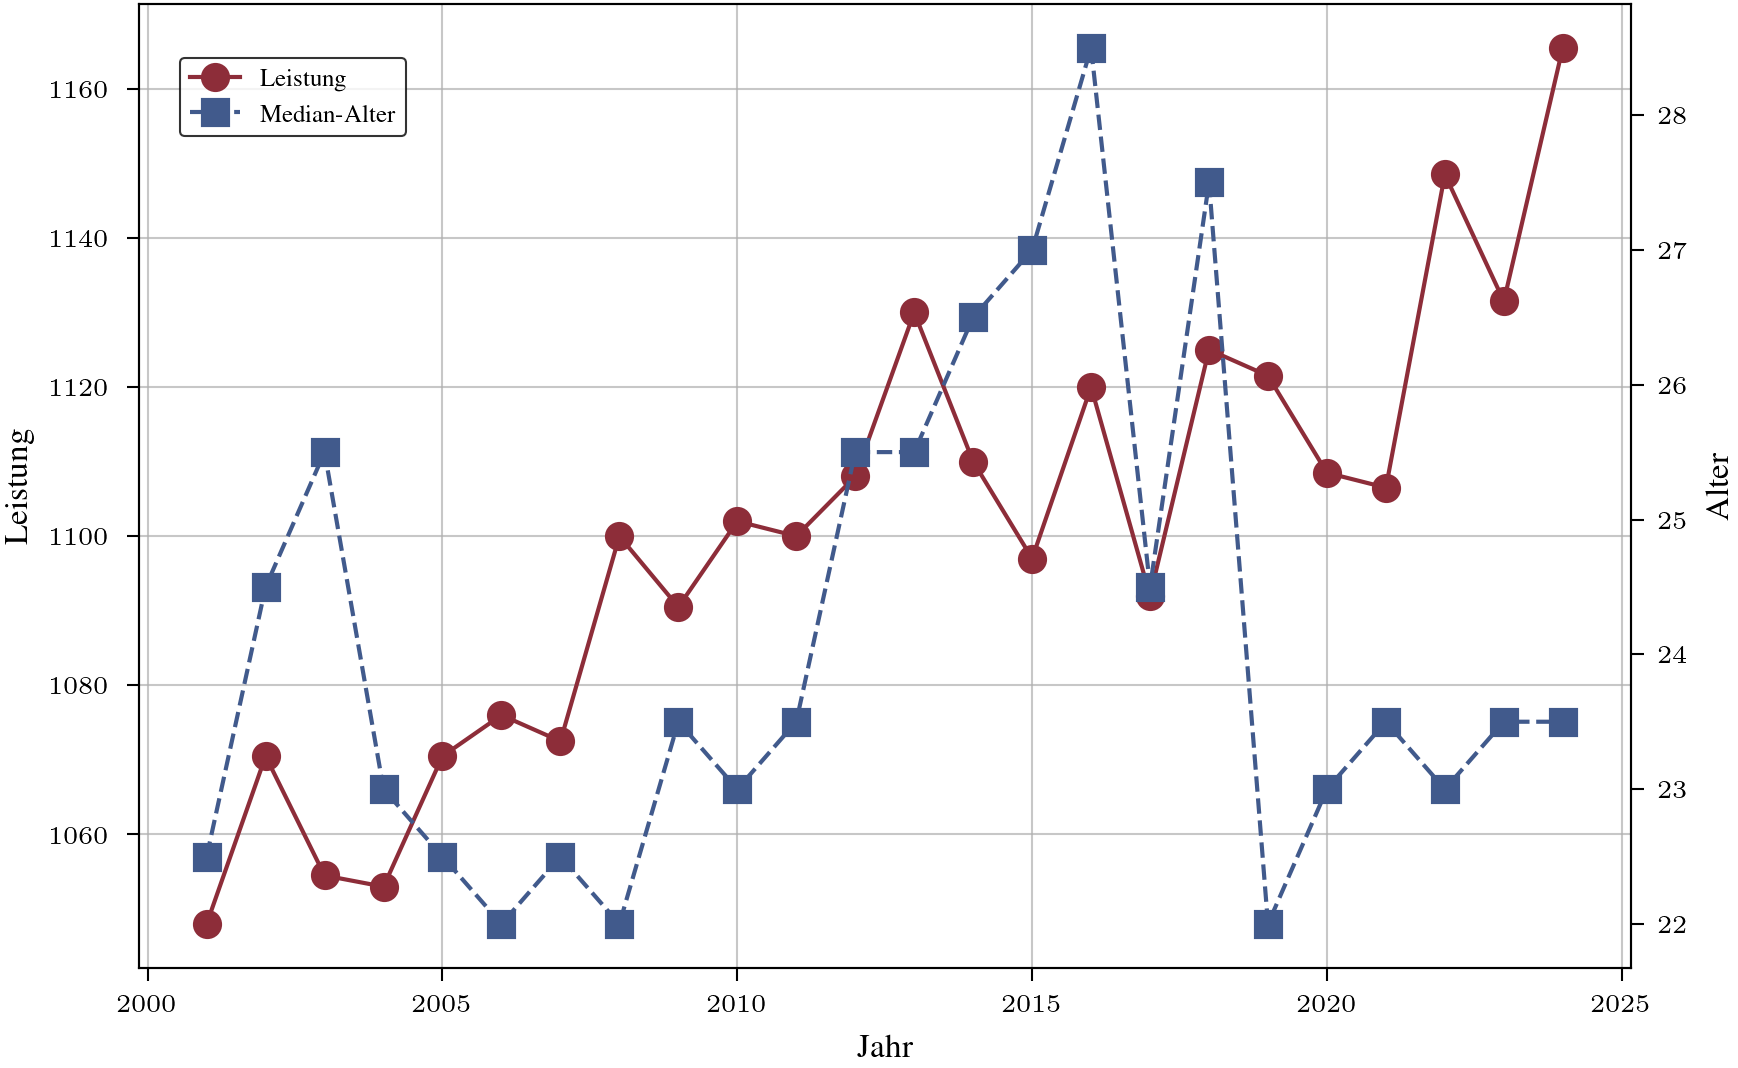

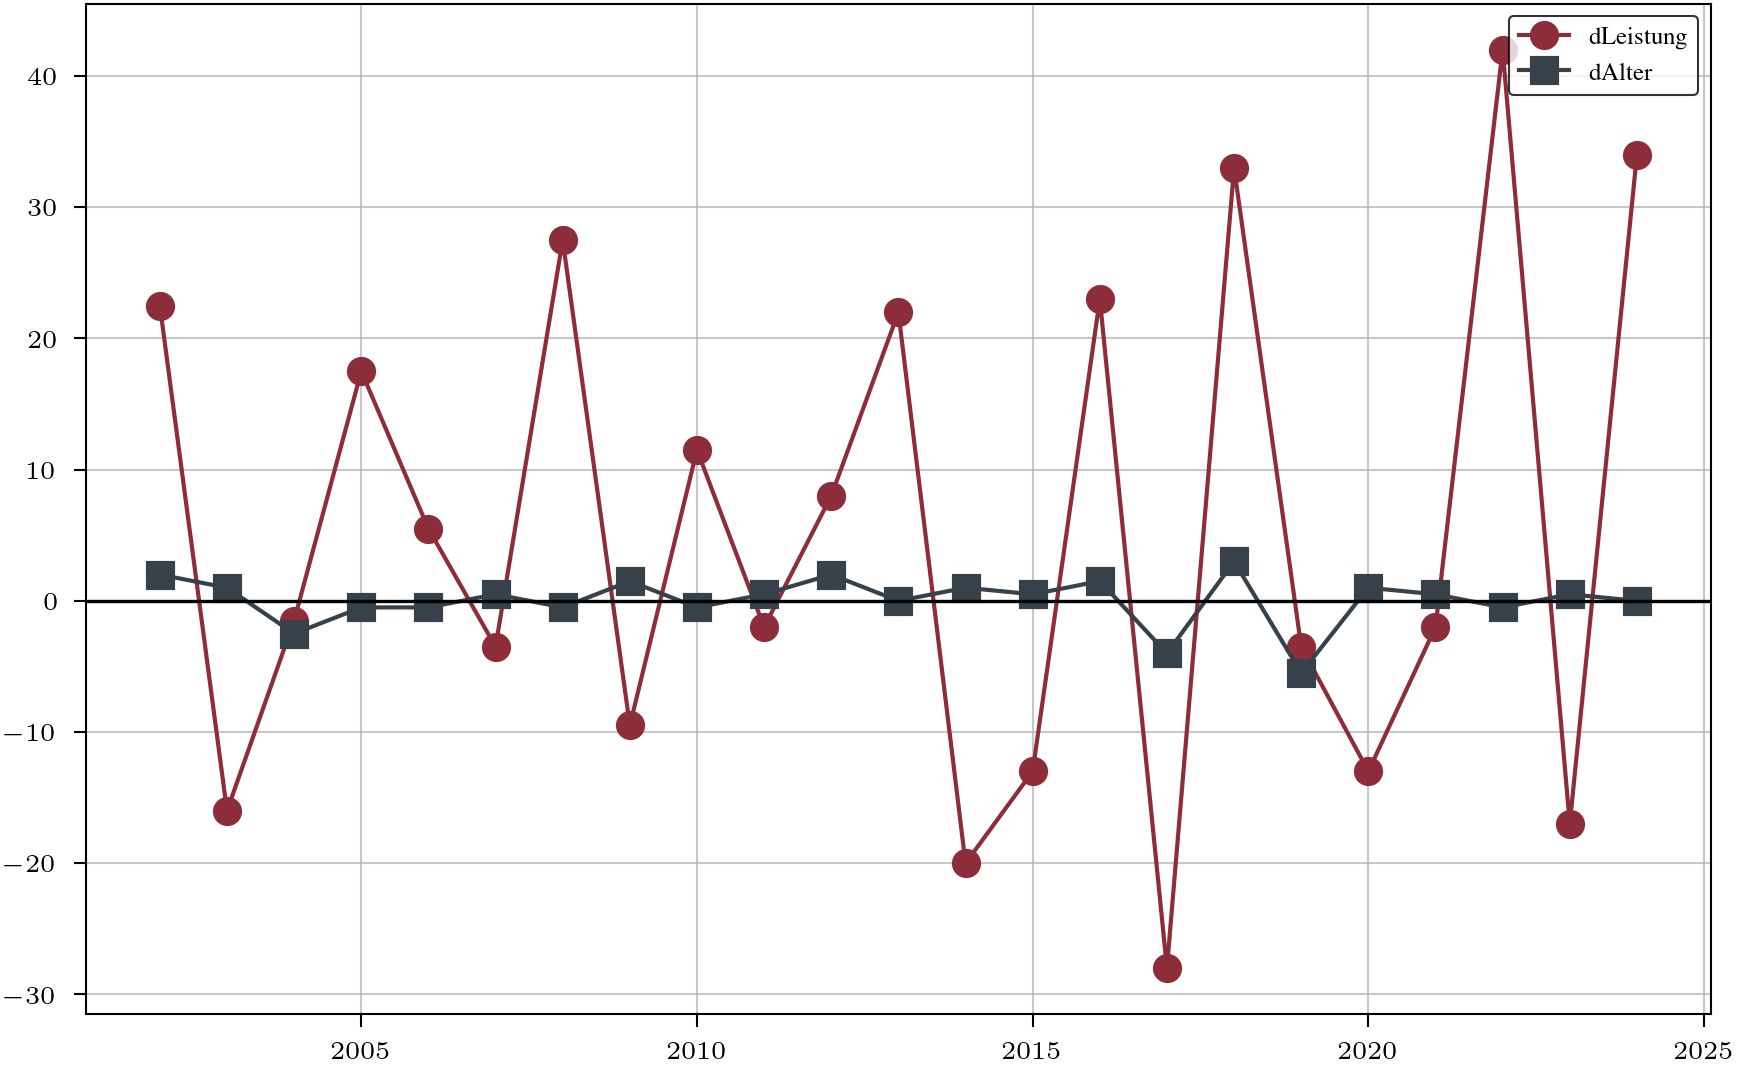

In [26]:
with plt.rc_context(plt.increase_figsize(1.8)):
    fig, ax = plt.subplots()

    ax.plot(
        sub['jahr'],
        sub['dL'],
        marker='o',
        label='dLeistung'
    )

    ax.plot(
        sub['jahr'],
        sub['dA_median'],
        marker='s',
        label='dAlter'
    )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    ax.grid()
    plt.show()

### **4. Lead-Lag-Logik (zeitliche Reihenfolge)**

Die eigentliche Frage lautet nun:

> Ist ΔA(t) statistisch mit ΔL(t+k) korreliert
> 

> für k > 0
> 
> 
> **oder**
> 

In [27]:
def lag_corr(x, y, max_lag=5):
    return {
        k: np.corrcoef(x[:-k], y[k:])[0,1]
        for k in range(1, max_lag+1)
    }

lag_A_to_L = lag_corr(
    ts['dA_median'].dropna().values,
    ts['dL'].dropna().values
)

lag_A_to_L

{1: np.float64(-0.006578096597019187),
 2: np.float64(0.07085775306846501),
 3: np.float64(0.027752324086849064),
 4: np.float64(0.02947848495967977),
 5: np.float64(0.036203335486951746)}

In [28]:
df_reg = ts.dropna(subset=['dL', 'dA_median'])

X = sm.add_constant(df_reg['dA_median'])
y = df_reg['dL']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     dL   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     27.95
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           1.52e-07
Time:                        13:04:28   Log-Likelihood:                -5071.6
No. Observations:                1039   AIC:                         1.015e+04
Df Residuals:                    1037   BIC:                         1.016e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2016      0.990      1.213      0.2

In [29]:
X2 = sm.add_constant(df_reg['dL'])
y2 = df_reg['dA_median']

sm.OLS(y2, X2).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              dA_median   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     27.95
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           1.52e-07
Time:                        13:04:28   Log-Likelihood:                -2152.4
No. Observations:                1039   AIC:                             4309.
Df Residuals:                    1037   BIC:                             4319.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0422      0.060     -0.707      0.480      -0.159       0.075
dL             0.0098      0.002      5.287      0.000       0.006       0.013
==============================================================================
Omnibus:                       84.915   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              462.327
Skew:                           0.009   Prob(JB):                    4.05e-101
Kurtosis:                       6.268   Cond. No.                         32.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/opt/homebrew/Caskroom/miniforge/base/envs/datalit/lib/python3.14/site-packages/ruptures/show/display.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


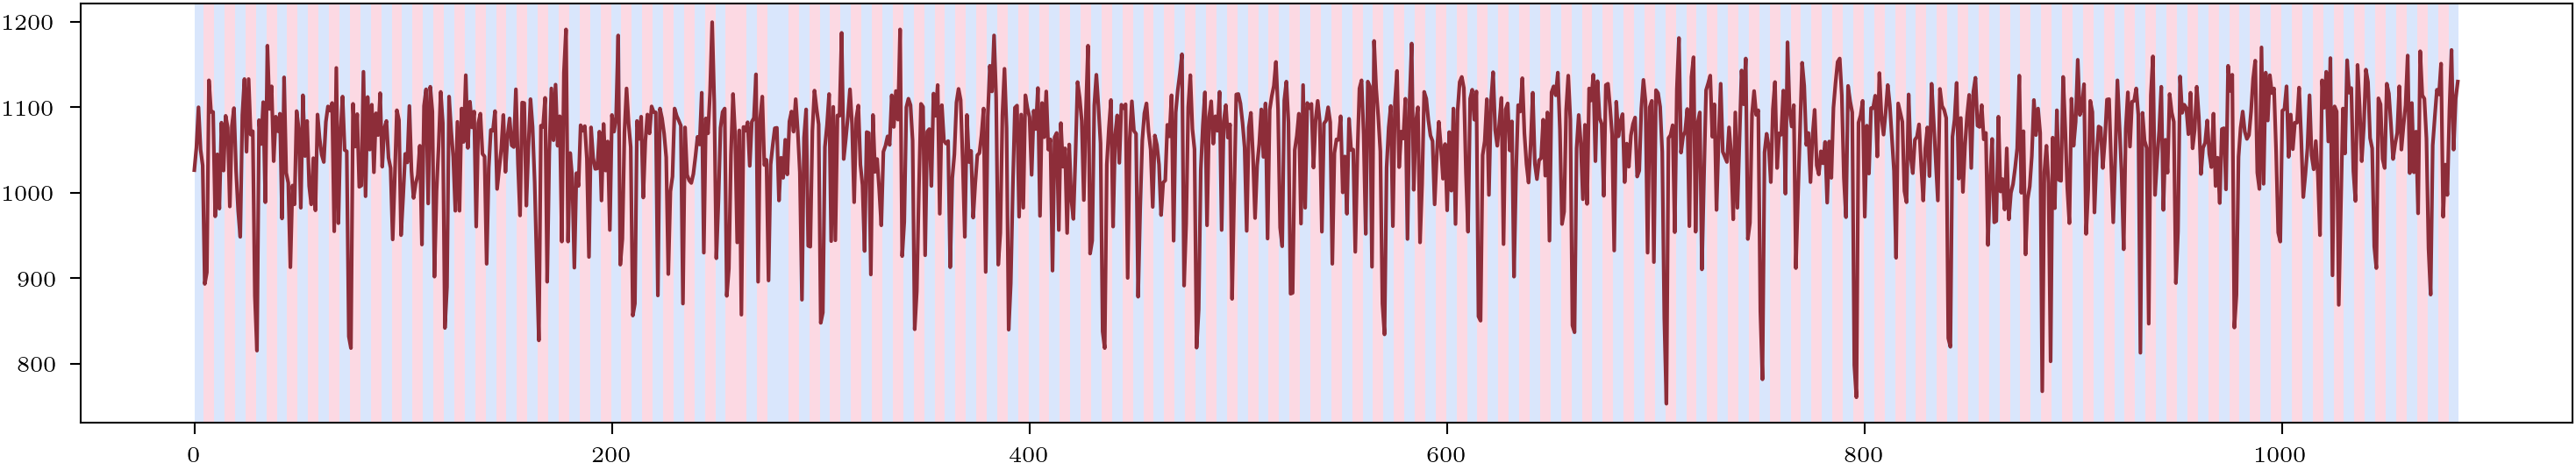

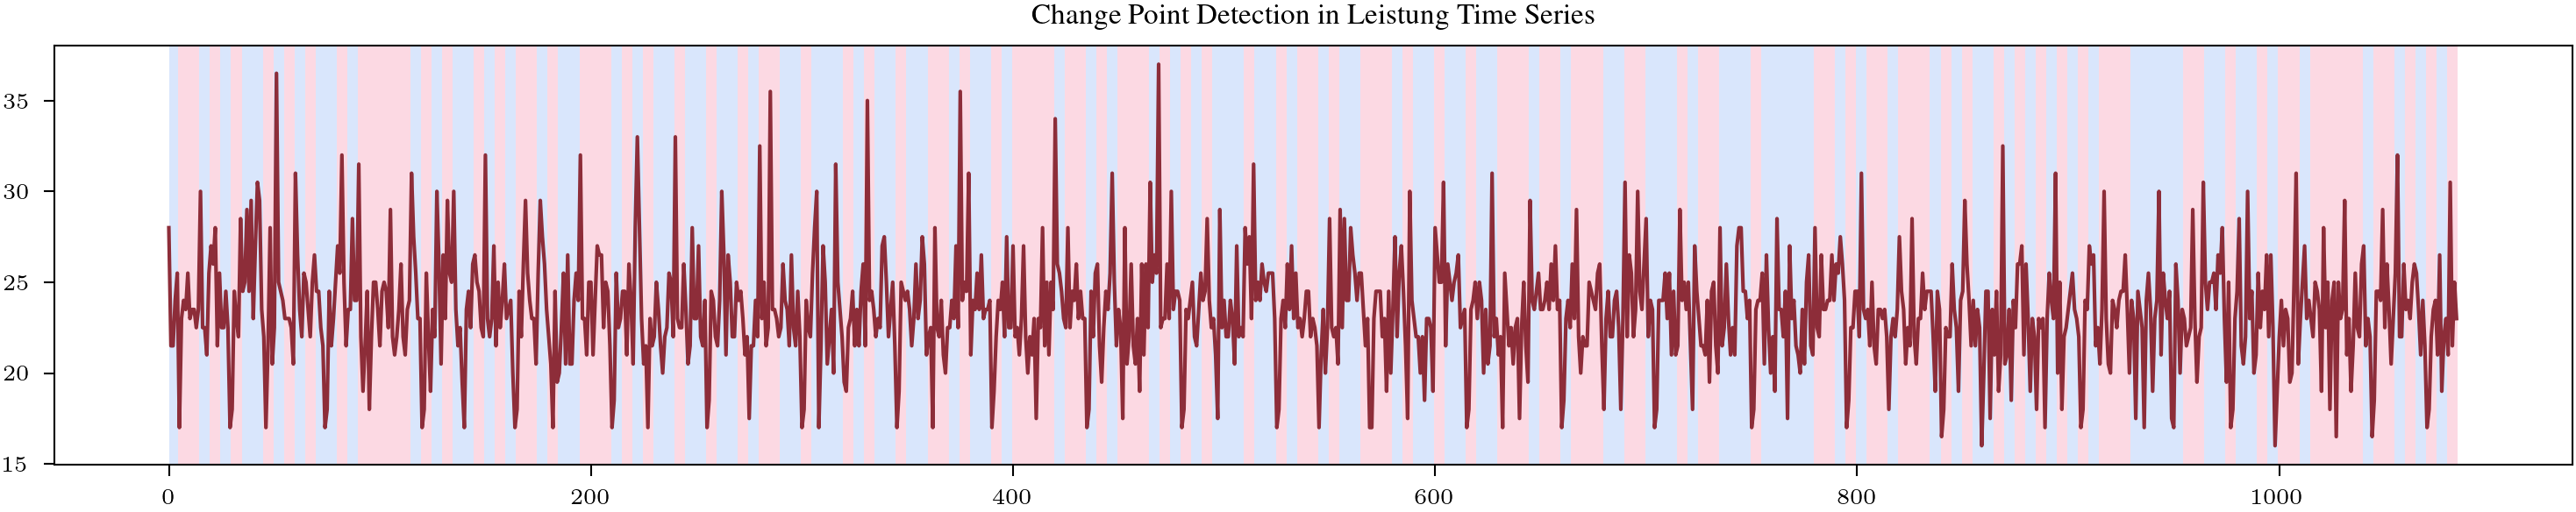

In [30]:
signal_L = ts['L'].values
signal_A = ts['A_median'].values

algo_L = rpt.Pelt().fit(signal_L).predict(pen=3)
algo_A = rpt.Pelt().fit(signal_A).predict(pen=3)

rpt.display(signal_L, algo_L)
rpt.display(signal_A, algo_A)
plt.title('Change Point Detection in Leistung Time Series')
plt.show()